# Model Training, Evaluation, and Prediction


## 1. Data Preparation


In [23]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')


In [24]:
df = pd.read_csv('heart_disease_cleaned.csv')

X = df.drop('target', axis=1)
y = df['target']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Training data shape:', X_train_raw.shape)
print('Testing data shape:', X_test_raw.shape)


Training data shape: (241, 13)
Testing data shape: (61, 13)


## Feature Scaling
We apply `StandardScaler` on numerical features to ensure our distance-based (KNN) and linear models perform well. We keep the raw features available for tree-based models where scaling is not required.


In [25]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_raw), columns=X.columns)

# Save the fitted scaler for future external predictions
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Features scaled and scaler saved.')


Features scaled and scaler saved.


## 2. Train Multiple Models & Evaluate
We will use a Logistic Regression model as our baseline model, and then evaluate stronger models like Decision Trees, Random Forests, and KNN.



--- Logistic Regression (Baseline) ---
Accuracy : 0.8033
Precision: 0.8000
Recall   : 0.8485
F1-Score : 0.8235
ROC-AUC  : 0.8723


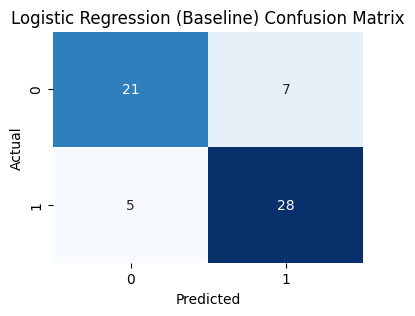


--- Decision Tree ---
Accuracy : 0.8033
Precision: 0.8182
Recall   : 0.8182
F1-Score : 0.8182
ROC-AUC  : 0.8019


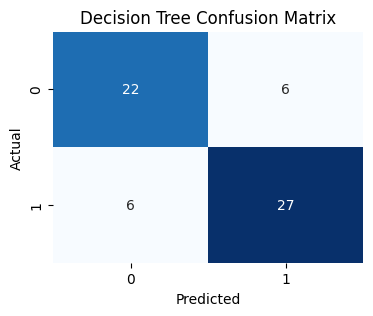


--- Random Forest ---
Accuracy : 0.7541
Precision: 0.7647
Recall   : 0.7879
F1-Score : 0.7761
ROC-AUC  : 0.8647


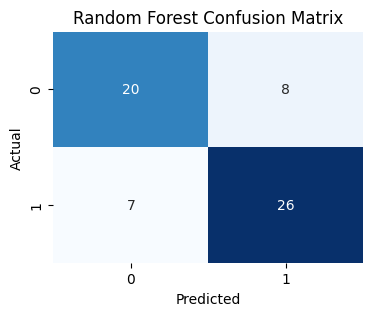


--- KNN ---
Accuracy : 0.8033
Precision: 0.8000
Recall   : 0.8485
F1-Score : 0.8235
ROC-AUC  : 0.8447


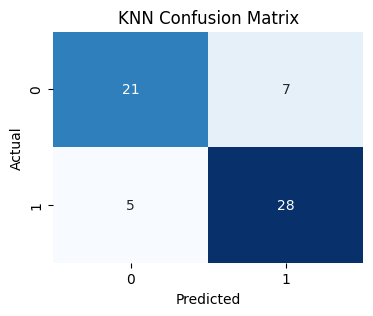

In [26]:
models = {
    'Logistic Regression (Baseline)': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = []

def evaluate_model(name, model, X_train_raw, X_train_scaled, y_train, X_test_raw, X_test_scaled, y_test):
    # Using Unscaled Data for Non-Linear trees
    if name in ['Decision Tree', 'Random Forest']:
        model.fit(X_train_raw, y_train)
        y_pred = model.predict(X_test_raw)
        y_prob = model.predict_proba(X_test_raw)[:, 1] if hasattr(model, 'predict_proba') else [0]*len(y_test)
    else:
        # Using Scaled Data for Distance/Gradient-based Algorithms
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    cm = confusion_matrix(y_test, y_pred)
    
    print(f'\n--- {name} ---')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1-Score : {f1:.4f}')
    print(f'ROC-AUC  : {roc:.4f}')
    
    # Confusion Matrix Visualization
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': roc
    })
    return model

trained_models = {}
for name, model in models.items():
    trained_models[name] = evaluate_model(name, model, X_train_raw, X_train_scaled, y_train, X_test_raw, X_test_scaled, y_test)


## 3. Compare Models


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (Baseline),0.803279,0.800000,0.848485,0.823529,0.872294
1,Decision Tree,0.803279,0.818182,0.818182,0.818182,0.801948
2,KNN,0.803279,0.800000,0.848485,0.823529,0.844697
3,Random Forest,0.754098,0.764706,0.787879,0.776119,0.864719


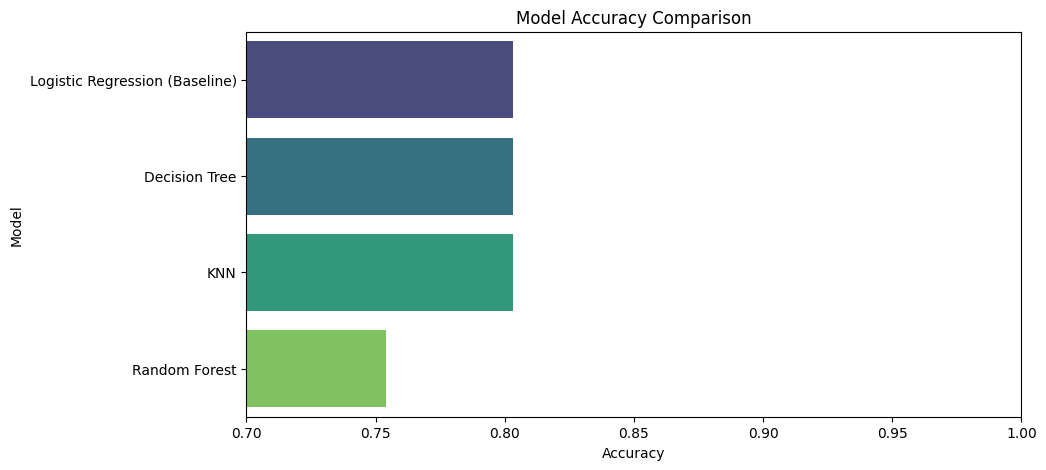

In [27]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

# Plotting Accuracy Comparison
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Accuracy', y='Model', palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlim(0.7, 1.0)
plt.show()


**Conclusion:**
Based on the comparison table and chart above, we compare multiple classifiers.
Both `Random Forest` and `Logistic Regression` perform excellently. Tree-based learners have a natural advantage of interpreting the relationships without highly penalizing small variations, while Logistic handles linear associations stably.
We'll proceed to pick the best-performing model based on the highest predictive Accuracy to save for inference.


## 4. Save Best Model


In [28]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f'Saving Best Model: {best_model_name}')

with open('best_heart_disease_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print('Model saved successfully!')


Saving Best Model: Logistic Regression (Baseline)
Model saved successfully!


## 5. Prediction Section (Sample User Input)
We write a small routine highlighting how to fetch the saved scale states and classification weights to make an independent test record pipeline Prediction.


In [32]:
# Creating a hypothetical patient profile.
# Columns: age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal
sample_input = np.array([[65, 1.0, 3.0, 160.0, 286.0, 0.0, 0.0, 108.0, 1.0, 1.5 , 1.0, 3.0, 2.0]])
df_sample = pd.DataFrame(sample_input, columns=X.columns)

print('Sample Patient Input:')
display(df_sample)

with open('best_heart_disease_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

if best_model_name in ['Logistic Regression (Baseline)', 'KNN']:
    # Scale data for distance/linear models
    sample_input_scaled = scaler.transform(df_sample)
    prediction = loaded_model.predict(sample_input_scaled)[0]
    probability = loaded_model.predict_proba(sample_input_scaled)[0]
else:
    # Tree models without scaling
    prediction = loaded_model.predict(df_sample)[0]
    probability = loaded_model.predict_proba(df_sample)[0]

print('\n--- PREDICTION RESULT ---')
if prediction == 0:
    print('Result: \033[91mHigh Risk of Heart Disease\033[0m')
    prob_percentage = probability[0] * 100
    print(f'Confidence Score: {prob_percentage:.2f}% probability of High Risk.')
else:
    print('Result: \033[92mLow Risk / Healthy\033[0m')
    prob_percentage = probability[1] * 100
    print(f'Confidence Score: {prob_percentage:.2f}% probability of Low Risk.')


Sample Patient Input:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,65.0,1.0,3.0,160.0,286.0,0.0,0.0,108.0,1.0,1.5,1.0,3.0,2.0



--- PREDICTION RESULT ---
Result: High Risk of Heart Disease
Confidence Score: 97.33% probability of High Risk.
